# NOTE: The purpose of this notebook is not to perform a deep dive or complex data analysis. It is specifically designed to demonstrate the functionality and usage of the edatoolkit library.

# 1. Environment Setup and Library Imports
In this initial step, we configure our development environment by importing the necessary libraries. We utilize **Pandas** for data manipulation and **Seaborn** to access built-in datasets for demonstration purposes. Most importantly, we import the custom `EDA` class from the `edatoolkit` package, which serves as the core engine for our automated analysis.

In [1]:
import pandas as pd
import seaborn as sns
from edatoolkit import EDA

# 2. Dataset Loading
In this step, we load the **Diamonds** dataset from the Seaborn library. This dataset contains the prices and other attributes of almost 54,000 diamonds, making it an excellent candidate for demonstrating how the toolkit handles a mix of numerical features (like price and carat) and categorical features (like cut and color).

In [2]:
df=sns.load_dataset('diamonds')

# 3. Class Initialization and Automatic Feature Engineering
In this step, we initialize the **EDA** class by passing our dataframe and specifying 'price' as the **target_col**. Upon instantiation, the class automatically executes the `get_columns_types` method, which categorizes features into numerical, categorical, or high-cardinality types based on predefined thresholds. This automated setup prepares the entire pipeline for statistical testing and visualization.

In [3]:
eda=EDA(df,'price')

# 4. Global Data Overview and Integrity Check
We execute the `check_dataframe()` method to perform a holistic inspection of the dataset. This automated diagnostic prints the head, tail, and a random sample of the data to verify loading consistency. It also reports critical metadata, including the total row and column counts, data types via `info()`, missing value (NaN) distributions, and the exact count and ratio of duplicate entries to ensure the dataset is clean and reliable.

In [4]:
eda.check_dataframe()


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                   Head                                                                                   
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75

───────────────────────────────────────────────────────────

# 5. Data Cleaning and State Synchronization
In this step, we perform essential data cleaning by removing duplicate rows to ensure statistical integrity. After modifying the dataset, we call the `update_dataframe()` method. This crucial function synchronizes the internal state of our **EDA** object with the cleaned data, automatically recalculating feature types and resetting any previous summaries to maintain consistency in the upcoming analysis.

In [5]:
df=df.drop_duplicates()
eda.update_dataframe(df)

Dataframe and column types have been successfully updated.


# 6. Feature Segmentation and Categorization Results
After initializing the automated pipeline, we inspect the results of the feature engineering logic. The toolkit separates the variables into four distinct categories:
* **cat_cols**: Standard categorical features.
* **num_cols**: Standard numerical features.
* **num_but_cat**: Numerical variables that behave like categories (low unique value count).
* **cat_but_car**: Categorical variables with extremely high cardinality (too many unique values).

The empty lists for `num_but_cat` and `cat_but_car` indicate that all features in the **Diamonds** dataset strictly align with their native data types according to the current thresholds.

In [6]:
eda.cat_cols

['cut', 'color', 'clarity']

In [7]:
eda.num_but_cat

[]

In [8]:
eda.num_cols

['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

In [9]:
eda.cat_but_car

[]

# 7. Comprehensive Descriptive Analysis
In this step, we execute the `descriptive_analysis()` method to extract deep statistical insights from our numerical features. Beyond standard measures of central tendency (mean, median) and dispersion (std, min, max), this method calculates advanced metrics including:
* **Percentiles**: Detailed distribution from 1% to 99% to identify data spread.
* **Coefficient of Variation (CV%)**: To assess the relative variability of features.
* **Skewness and Kurtosis**: To mathematically describe the asymmetry and "tailedness" of the distributions.

This granular table provides a complete profile of each numerical variable before we move into visual diagnostics.

In [10]:
eda.descriptive_analysis()


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                           Descriptive Analysis                                                                           
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         count         mean          std    min      1%      5%     25%      50%      75%       95%       99%       max   median      cv%  skewness   kurtosis
carat  53794.0     0.797780     0.473390    0.2    0.24    0.30    0.40     0.70     1.04      1.70      2.18      5.01     0.70   59.338  1.113651   1.247158
depth  53794.0    61.748080     1.429909   43.0   57.90   59.30   61.00    61.80    62.50     63.80     65.60     79.00    61.80    2.316 -0.114250   5.412989
table  53

# 8. Visual Diagnostics and Normality Testing
In this step, we execute the `check_num()` method to perform a rigorous evaluation of our numerical features. For each column, the toolkit generates a multi-panel visual diagnostic consisting of a **Q-Q Plot**, **Histogram**, and **Box Plot**. Simultaneously, it runs a formal statistical test (**Shapiro-Wilk** for smaller samples or **D'Agostino K²** for larger ones) to calculate p-values for Gaussian distribution. This combination of visual and mathematical evidence is essential for deciding whether to use parametric or non-parametric methods in the subsequent analysis.


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                        Numerical Variable Summary                                                                        
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


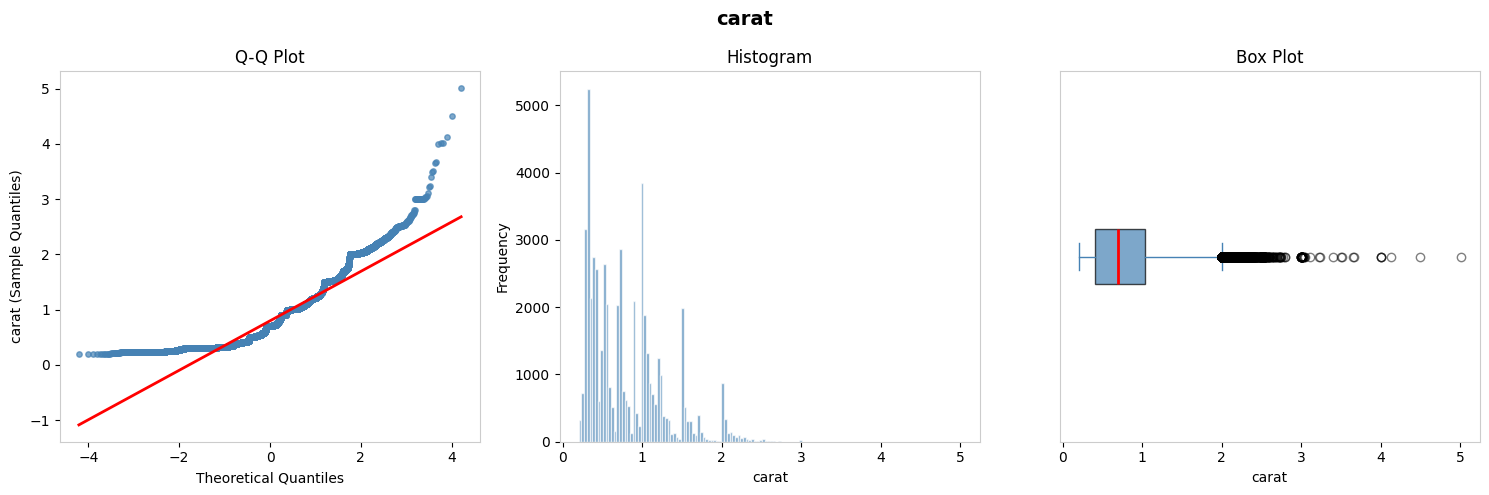

Column: carat
Test: D'Agostino K²
Test Statistic: 8859.6803, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


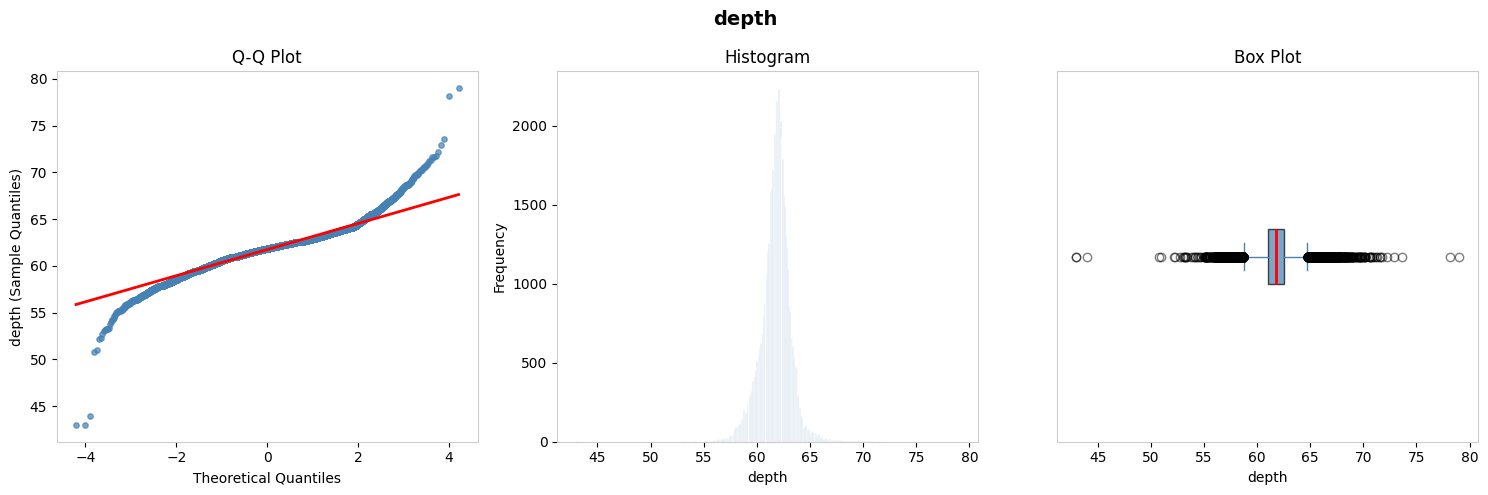

Column: depth
Test: D'Agostino K²
Test Statistic: 6375.6598, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


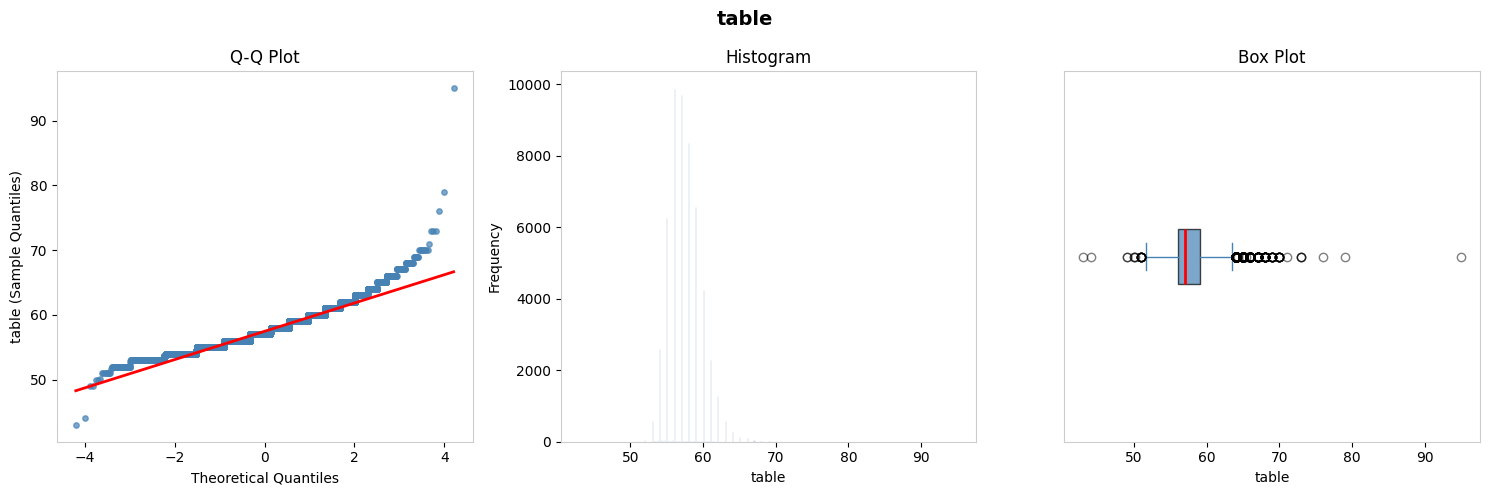

Column: table
Test: D'Agostino K²
Test Statistic: 7937.6443, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


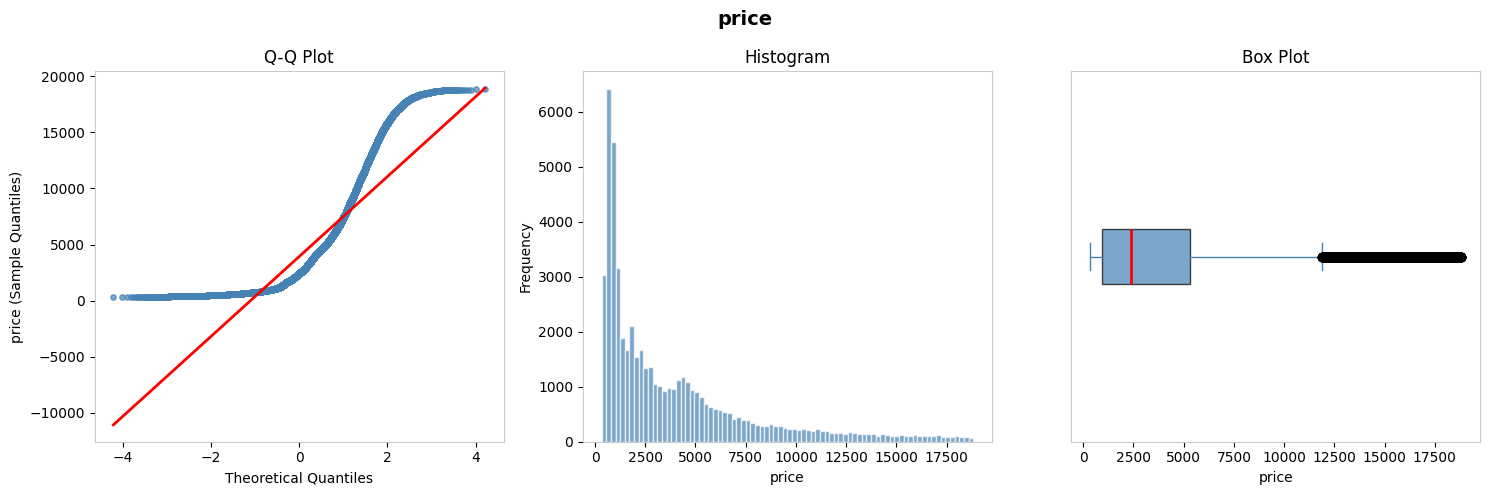

Column: price
Test: D'Agostino K²
Test Statistic: 15055.3697, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


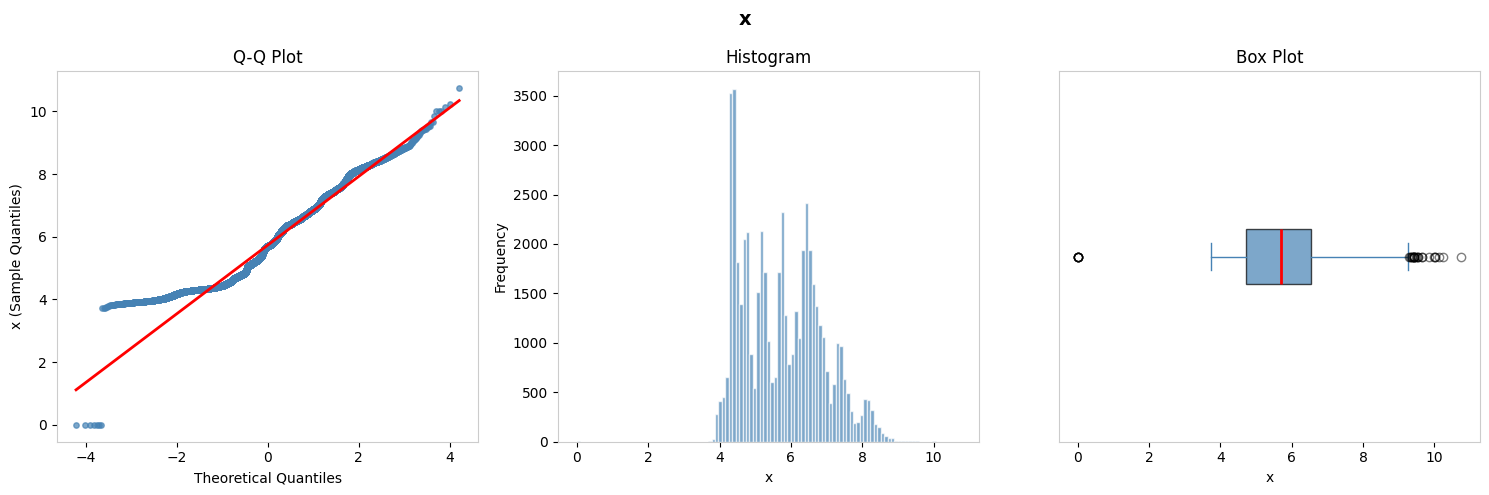

Column: x
Test: D'Agostino K²
Test Statistic: 3223.4564, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


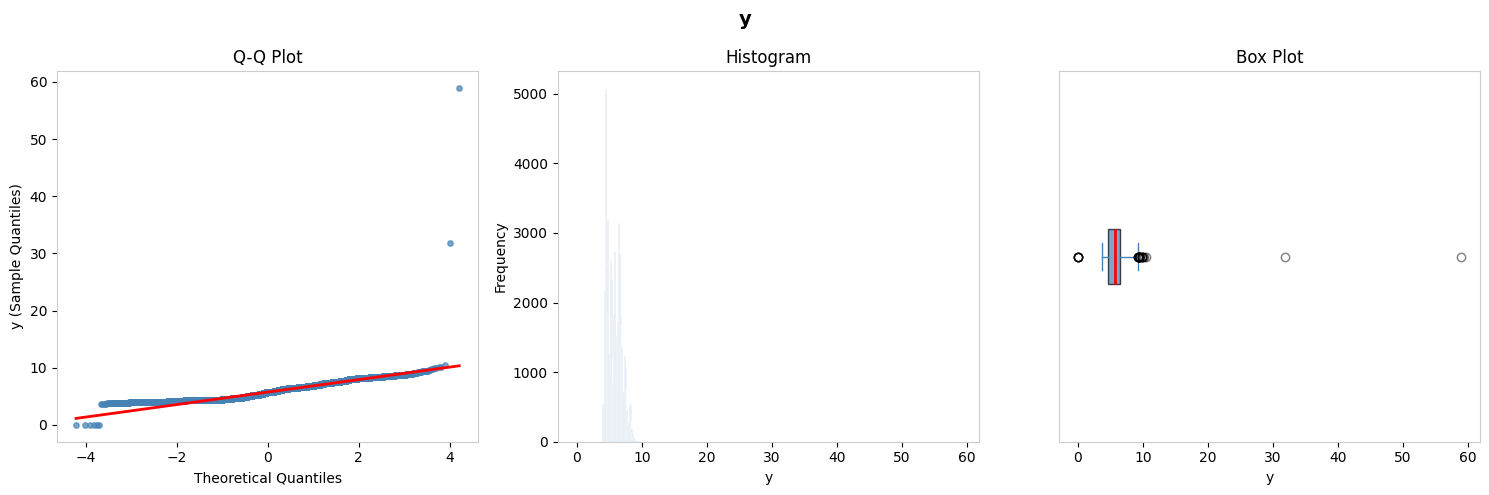

Column: y
Test: D'Agostino K²
Test Statistic: 40330.3692, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


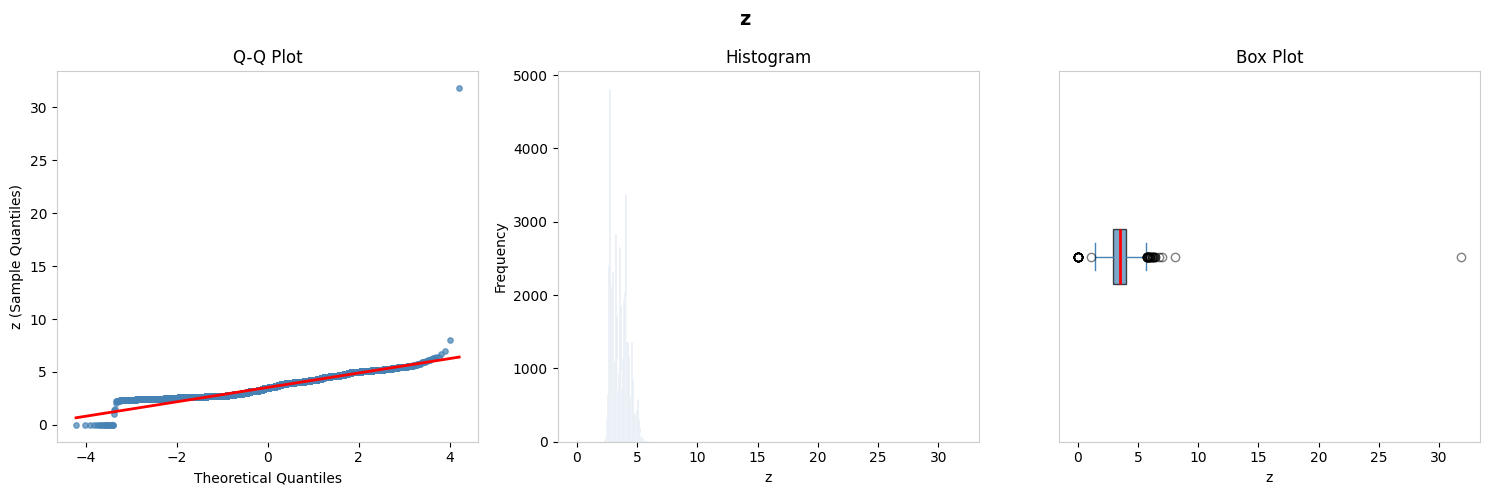

Column: z
Test: D'Agostino K²
Test Statistic: 29002.2520, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Note: The results above are based on statistical tests only. 
Please verify using the visuals before making a final decision. 
To manually set normality, pass result_dict={'col_name': 'Normal/Non-normal'} 
to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Columns flagged as Non-normal by the test — please verify visually: ['carat', 'depth', 'table', 'pr

['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

In [11]:
eda.check_num(plot=True)

# 9. Manual Normality Assignment and Strategy Mapping
In this stage, we do not rely solely on automated p-values. By synthesizing the visual evidence from the **Q-Q Plots** and **Histograms** with the statistical test results, we manually assign each variable's distribution status. We pass these final decisions via a mapping dictionary to the `num_summary()` method. This step is vital as it acts as a "strategy selector" for the class—telling the toolkit whether to apply **Parametric** or **Non-parametric** logic for all future outlier handling and hypothesis testing.

In [12]:
result_dict={
'carat':'Non-normal',
'depth':'Non-normal',
'table':'Non-normal',
'price':'Non-normal',
'x':'Non-normal',
'y':'Non-normal',
'z':'Non-normal'
}

In [13]:
eda.num_summary(result_dict=result_dict)

,Column,Result
0,carat,Non-normal
1,depth,Non-normal
2,table,Non-normal
3,price,Non-normal
4,x,Non-normal
5,y,Non-normal
6,z,Non-normal


# 10. Robust Outlier Management: Capping and Remediation
In this step, we execute the `check_outlier()` method with the `cap=True` parameter to handle extreme values without losing data rows. Based on our previous distribution mapping, the toolkit automatically applies the **Z-score** method for normal features and the **Interquartile Range (IQR)** method for non-normal features. By "capping," we replace values outside the calculated boundaries with the upper or lower limits (winsorization), effectively neutralizing the impact of outliers while preserving the sample size for the upcoming bivariate and multivariate analyses.

In [14]:
eda.check_outlier(cap=True)


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                            Outlier Detection                                                                             
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Column: carat | Method: IQR | Outliers: 1873 (3.48%)
  → 'carat' capped at [-0.5600, 2.0000]
Column: depth | Method: IQR | Outliers: 2525 (4.69%)
  → 'depth' capped at [58.7500, 64.7500]
Column: table | Method: IQR | Outliers: 604 (1.12%)
  → 'table' capped at [51.5000, 63.5000]
Column: price | Method: IQR | Outliers: 3523 (6.55%)
  → 'price' capped at [-5612.6250, 11890.3750]
Column: x | Method: IQR | Outliers: 31 (0.06%)
  → 'x' capped at [1.9650, 9.2850]
Column: y | Method: IQR 

({'carat': {'method': 'IQR',
   'outlier_count': 1873,
   'outlier_ratio': 0.03481800944343235},
  'depth': {'method': 'IQR',
   'outlier_count': 2525,
   'outlier_ratio': 0.04693832025876492},
  'table': {'method': 'IQR',
   'outlier_count': 604,
   'outlier_ratio': 0.011228017994571885},
  'price': {'method': 'IQR',
   'outlier_count': 3523,
   'outlier_ratio': 0.06549057515708072},
  'x': {'method': 'IQR',
   'outlier_count': 31,
   'outlier_ratio': 0.0005762724467412723},
  'y': {'method': 'IQR',
   'outlier_count': 28,
   'outlier_ratio': 0.0005205041454437297},
  'z': {'method': 'IQR',
   'outlier_count': 48,
   'outlier_ratio': 0.0008922928207606796}},
        carat        cut color clarity  depth  table   price     x     y     z
 0       0.23      Ideal     E     SI2  61.50   55.0   326.0  3.95  3.98  2.43
 1       0.21    Premium     E     SI1  59.80   61.0   326.0  3.89  3.84  2.31
 2       0.23       Good     E     VS1  58.75   63.5   327.0  4.05  4.07  2.31
 3       0.29   

# 11. Distribution Re-evaluation and Final Normality Mapping
Since the outlier capping process (winsorization) modifies the extreme values of our numerical features, the overall distribution characteristics may have shifted. In this step, we re-run the `check_num()` method to observe the impact of capping on our histograms and Q-Q plots. After this  visual and statistical verification, we update our `result_dict` and pass it to `num_summary()`. This ensures that all subsequent hypothesis tests and bivariate analyses are based on the most accurate and up-to-date distribution status of our cleaned data.


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                        Numerical Variable Summary                                                                        
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


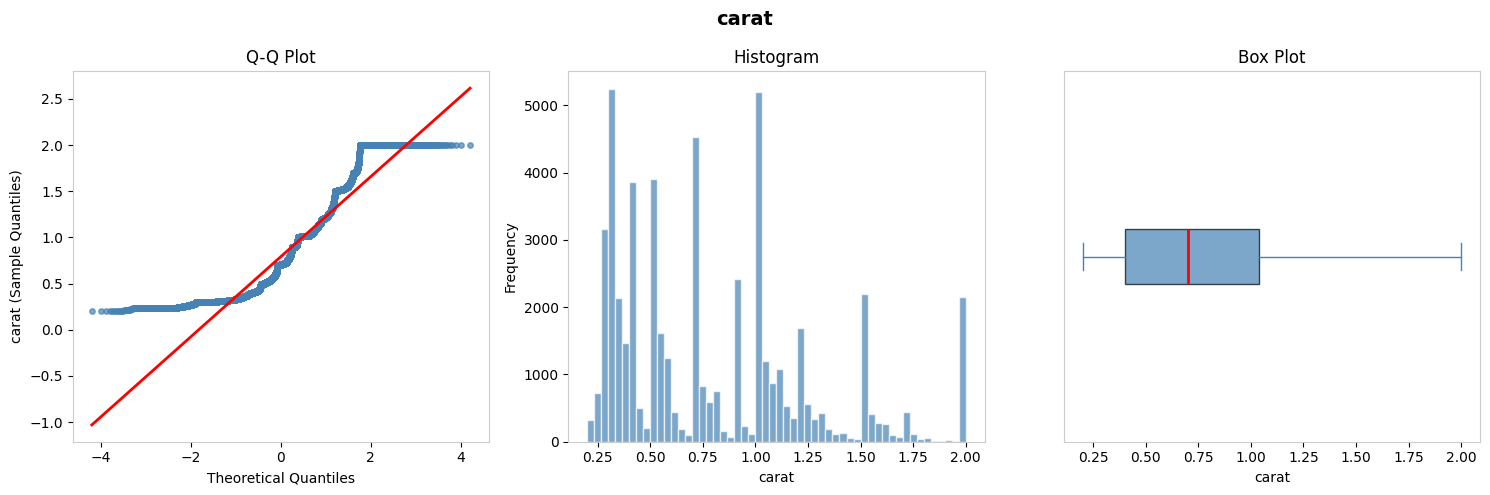

Column: carat
Test: D'Agostino K²
Test Statistic: 5435.1004, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


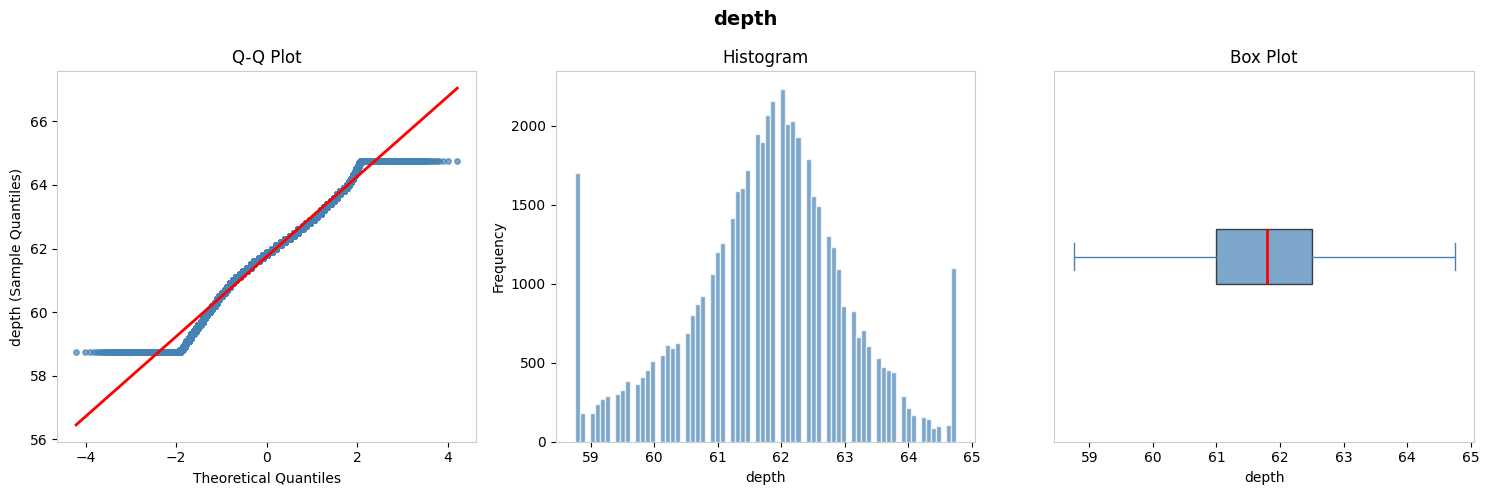

Column: depth
Test: D'Agostino K²
Test Statistic: 501.6246, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


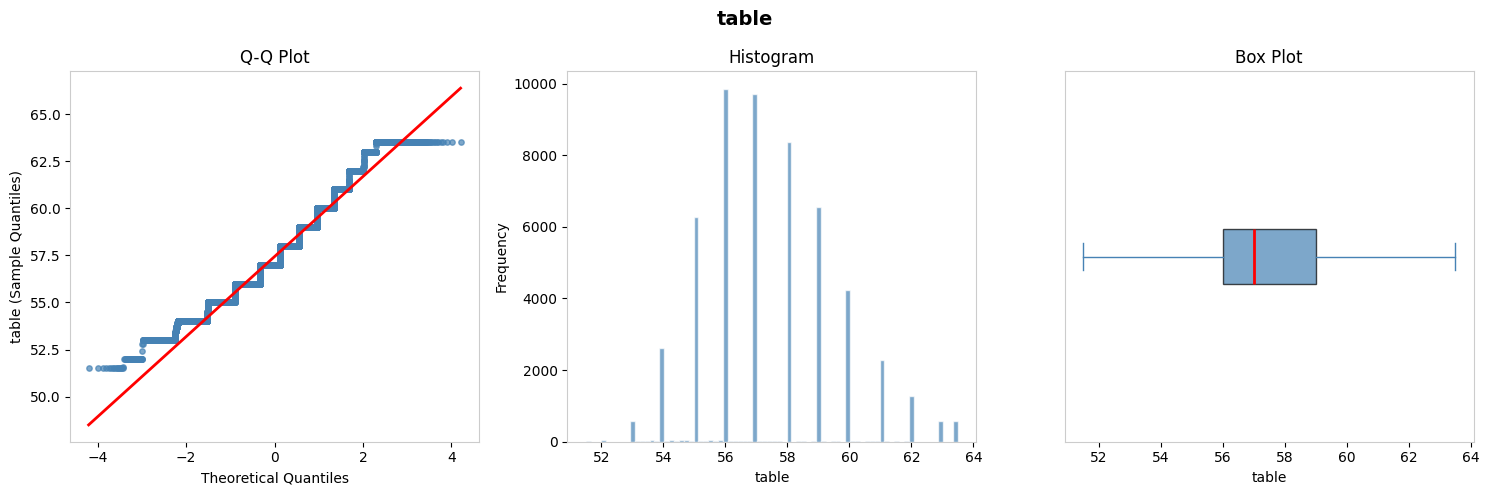

Column: table
Test: D'Agostino K²
Test Statistic: 1813.9045, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


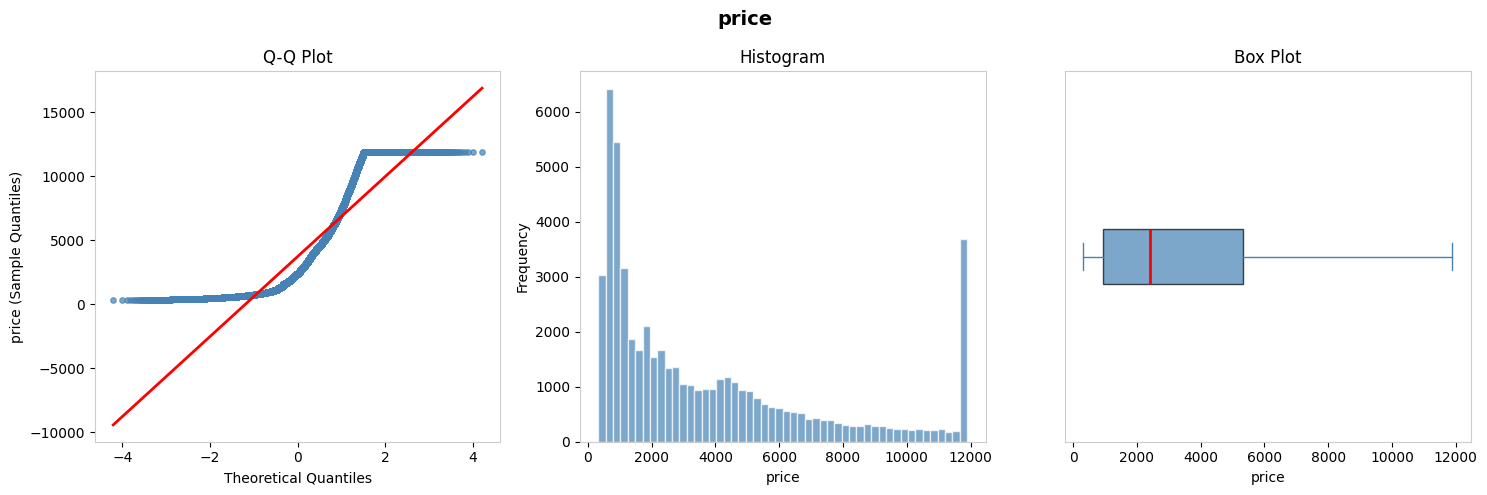

Column: price
Test: D'Agostino K²
Test Statistic: 7882.3168, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


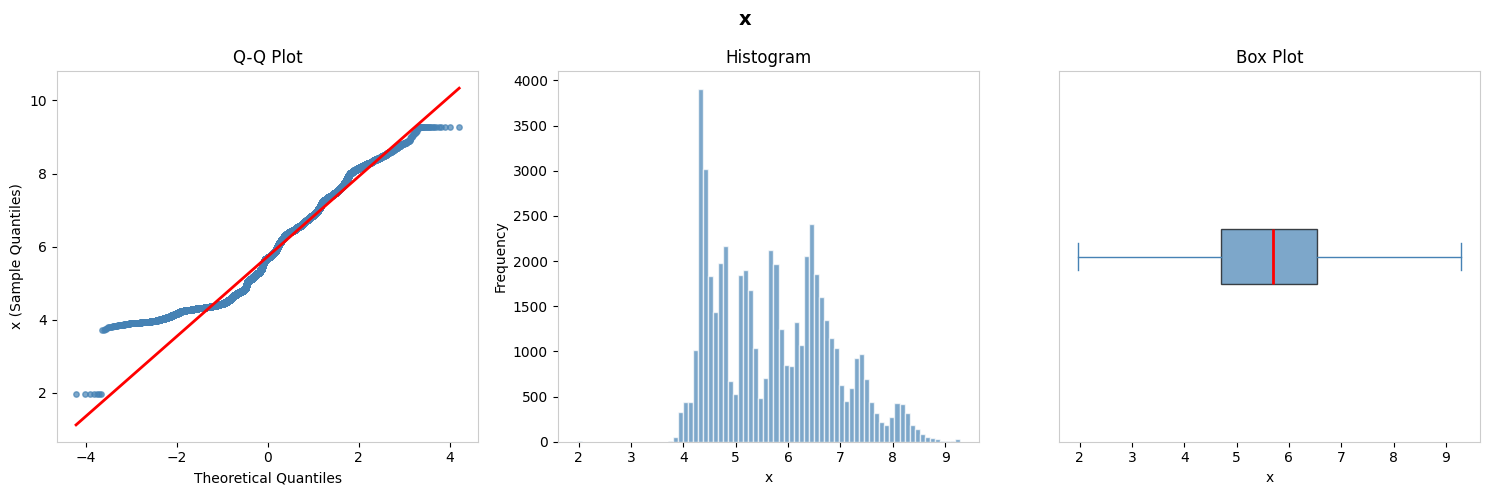

Column: x
Test: D'Agostino K²
Test Statistic: 4292.7244, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


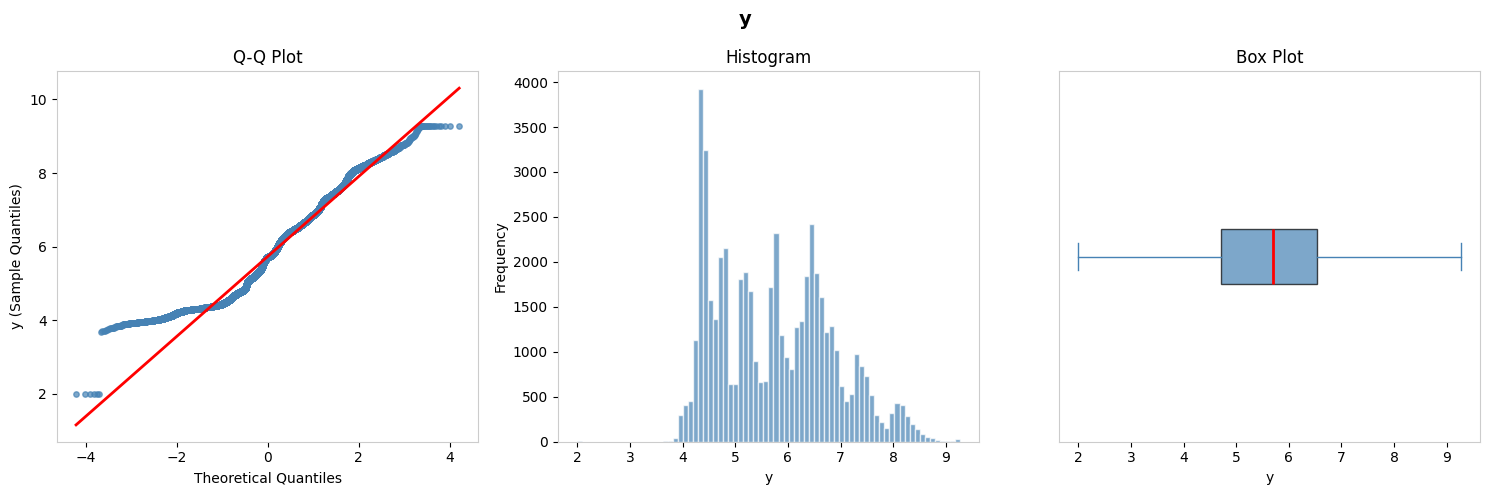

Column: y
Test: D'Agostino K²
Test Statistic: 4404.7543, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


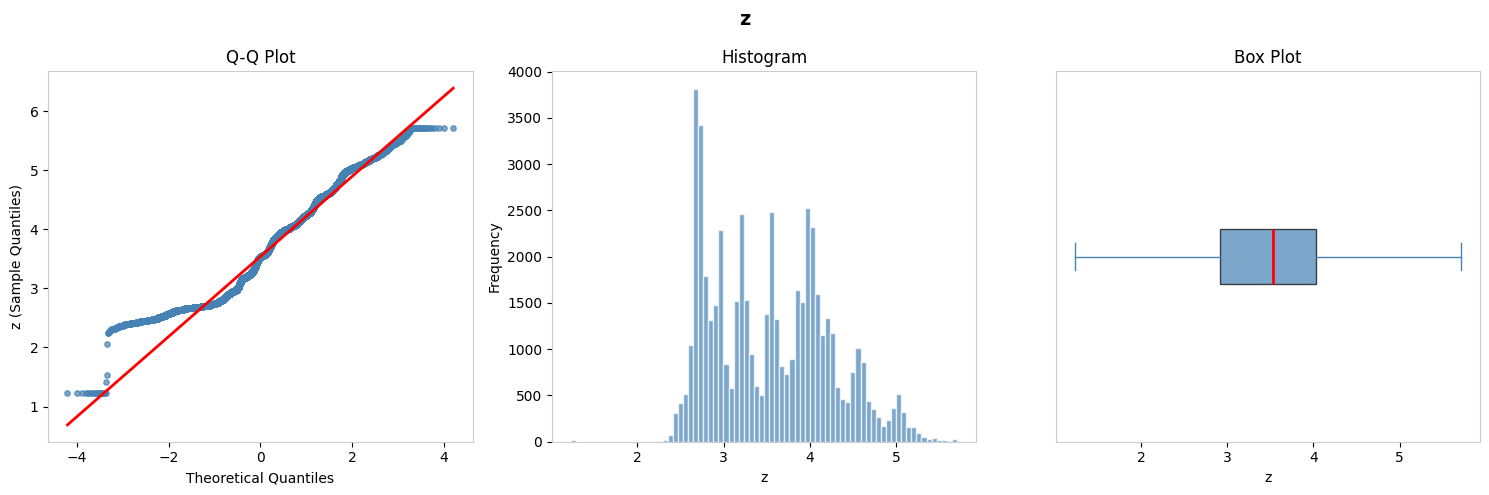

Column: z
Test: D'Agostino K²
Test Statistic: 4067.3154, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Note: The results above are based on statistical tests only. 
Please verify using the visuals before making a final decision. 
To manually set normality, pass result_dict={'col_name': 'Normal/Non-normal'} 
to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Columns flagged as Non-normal by the test — please verify visually: ['carat', 'depth', 'table', 'pri

['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

In [15]:
eda.check_num(plot=True)

In [16]:
eda.num_summary(result_dict)

,Column,Result
0,carat,Non-normal
1,depth,Non-normal
2,table,Non-normal
3,price,Non-normal
4,x,Non-normal
5,y,Non-normal
6,z,Non-normal


# 12. Categorical Variable Profiling and Distribution
With the numerical cleaning complete, we transition to analyzing the qualitative side of the dataset using the `cat_summary()` method. This automated function iterates through all identified categorical features, providing a frequency table that includes absolute counts and percentage ratios for each class. It also generates bar charts to visually identify class imbalances or dominant categories. This profiling is essential for understanding the distribution of diamond qualities (like cut, color, and clarity) before analyzing their impact on the final price.


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                       Categorical Variable Summary                                                                       
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Column: cut
           Count      Ratio
cut                        
Ideal      21488  39.944975
Premium    13748  25.556754
Very Good  12069  22.435588
Good        4891   9.092092
Fair        1598   2.970592


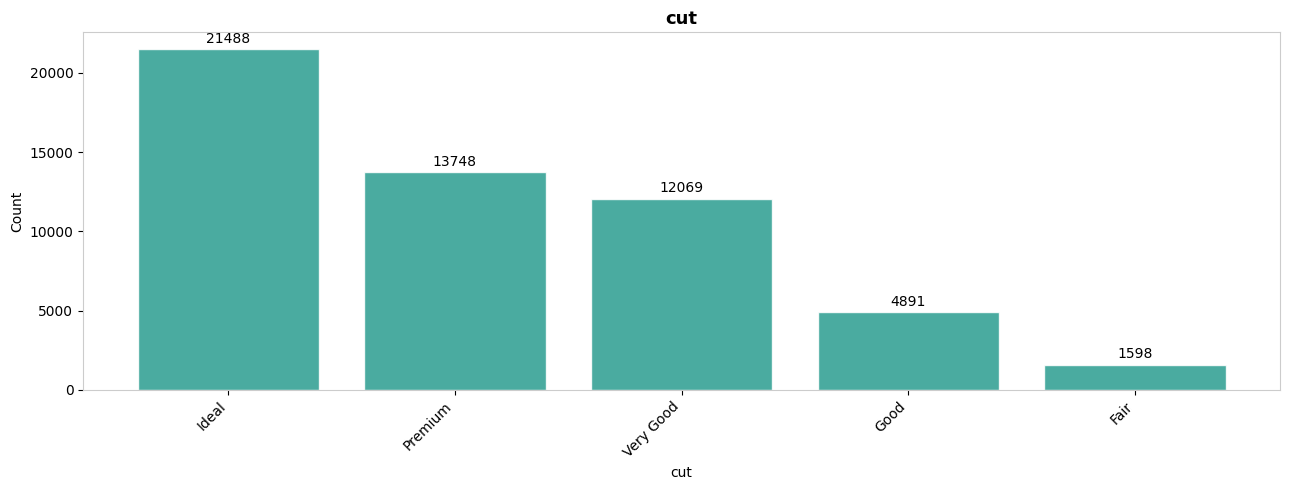


Column: color
       Count      Ratio
color                  
G      11262  20.935420
E       9776  18.173030
F       9520  17.697141
H       8272  15.377180
D       6755  12.557163
I       5407  10.051307
J       2802   5.208759


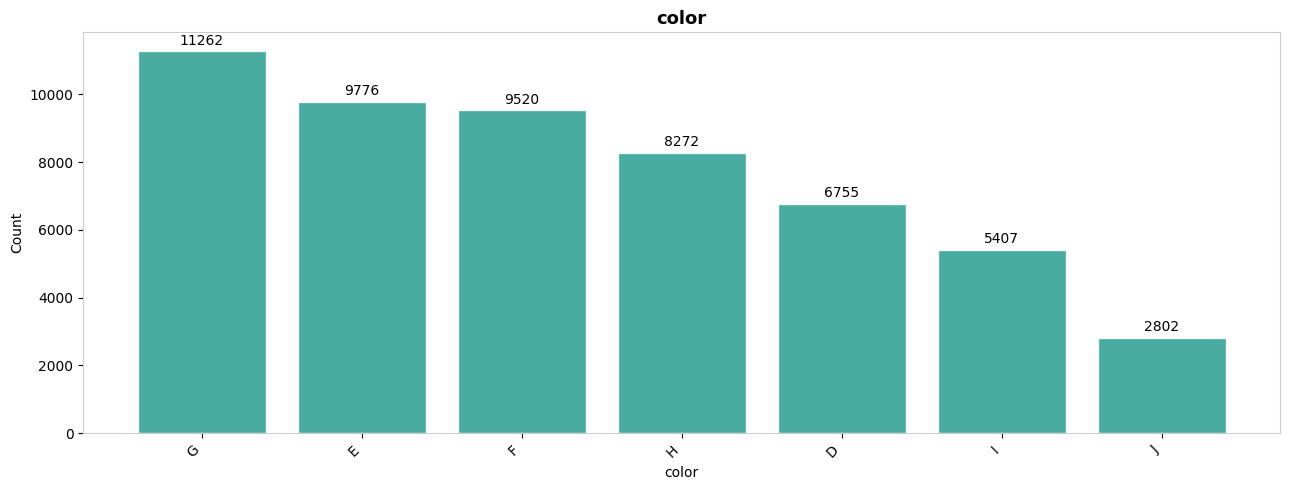


Column: clarity
         Count      Ratio
clarity                  
SI1      13032  24.225750
VS2      12229  22.733019
SI2       9150  17.009332
VS1       8156  15.161542
VVS2      5056   9.398818
VVS1      3647   6.779566
IF        1784   3.316355
I1         740   1.375618


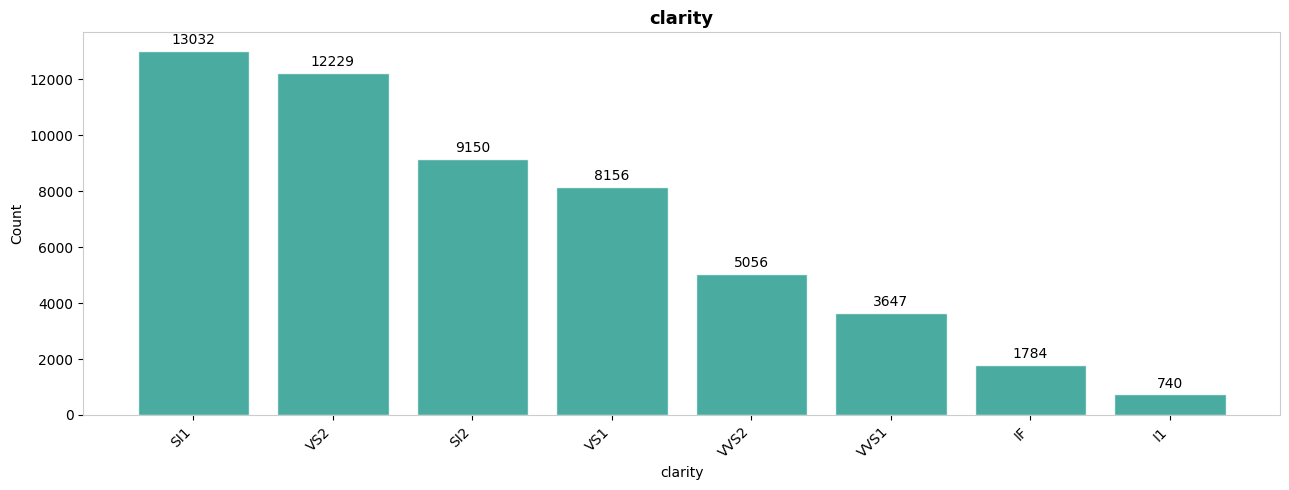

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [17]:
eda.cat_summary(plot=True)

# 13. Bivariate Analysis: Categorical Features vs. Target
In this critical step, we explore the relationship between our categorical features and the numerical target ('price') using the `target_summary_with_cat()` method. This automated analysis performs several key functions:
* **Grouped Statistics**: It calculates the mean, median, and count of the target variable for each category.
* **Hypothesis Testing**: Based on the number of groups and the distribution status of the target, it automatically selects and executes the appropriate statistical test (**Independent T-test**, **ANOVA**, or **Kruskal-Wallis**) to determine if the differences between categories are statistically significant.
* **Visualization**: It generates box plots to visually compare the distribution of the target across different classes, providing a clear view of how features like 'cut' or 'clarity' impact the diamond's value.


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                Target Analysis with Categorical Variables                                                                
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                  mean  median  count
                 price   price  price
cut                                  
Ideal      3301.707174  1813.0  21488
Premium    4302.618163  3182.0  13748
Very Good  3787.422529  2647.0  12069
Good       3749.558628  3042.0   4891
Fair       4168.664033  3282.0   1598


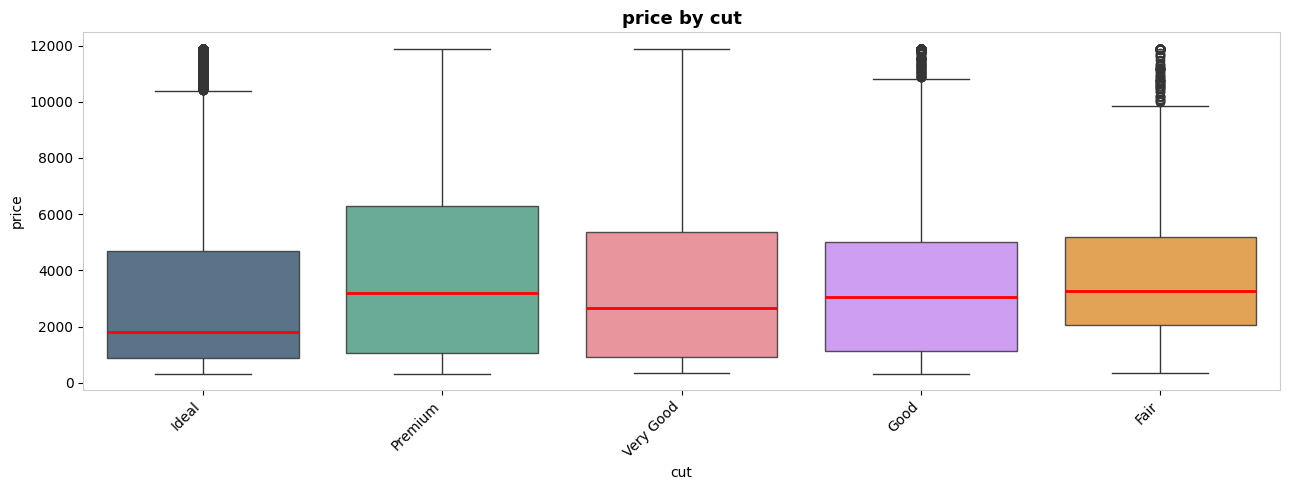


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                           Kruskal-Wallis Test                                                                            
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
P-value: 0.000000.
 H₀ REJECTED: Significant difference found.
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
              mean  median  count
             price   price  price
color                            
D      3061.690914  1842.0   6755
E      2967.886623  1741.5   9776
F      3560.790783  2345.0   9520
G      3804.622658  2246.0  11262
H      4231.14

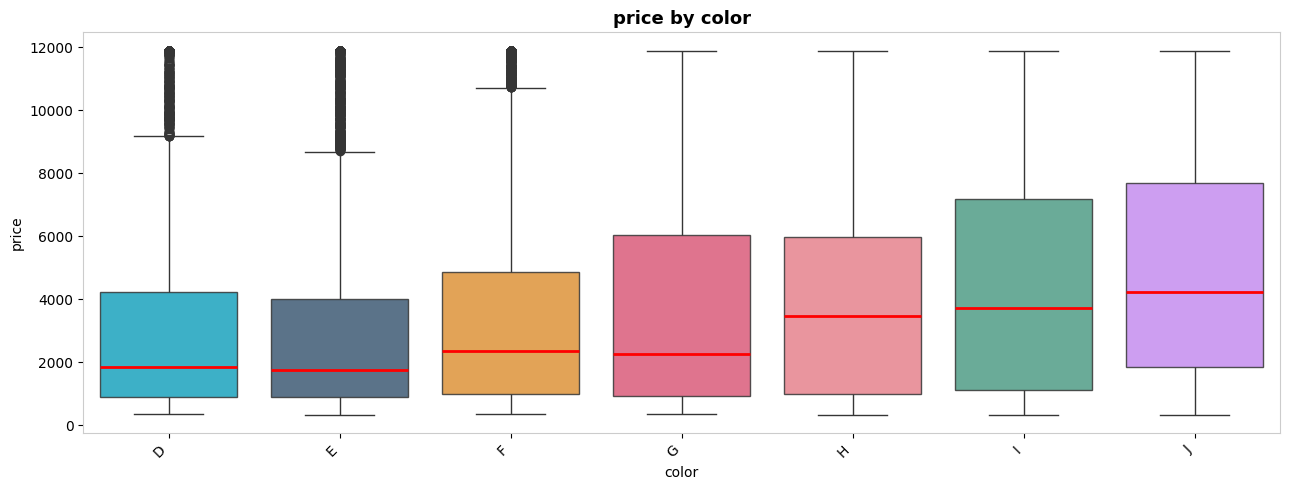


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                           Kruskal-Wallis Test                                                                            
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
P-value: 0.000000.
 H₀ REJECTED: Significant difference found.
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                mean  median  count
               price   price  price
clarity                            
IF       2690.485006  1080.0   1784
VVS1     2440.161023  1094.0   3647
VVS2     3183.995204  1316.0   5056
VS1      3661.624724  2010.0   8156


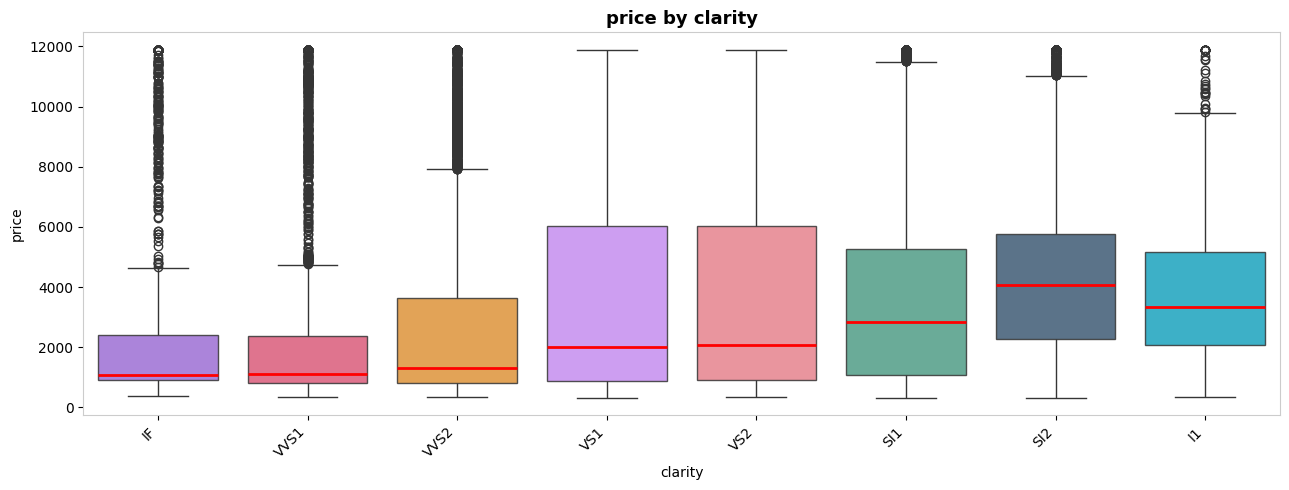


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                           Kruskal-Wallis Test                                                                            
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
P-value: 0.000000.
 H₀ REJECTED: Significant difference found.
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [18]:
eda.target_summary_with_cat(plot=True)

# 14. Bivariate Analysis: Numerical Features vs. Target
In this step, we use the `target_summary_with_num()` method to analyze the relationship between our numerical predictors and the 'price' target. This method performs a dual-layered analysis:
* **Statistical Correlation:** It calculates the **Pearson** (linear) or **Spearman** (rank-based) correlation coefficients to quantify the strength and direction of the relationship.
* **Visual Trend Analysis:** It generates interactive scatter plots with integrated trendlines. This allows us to visually detect non-linear patterns, heteroscedasticity, or specific clusters in the data (e.g., how 'carat' weight exponentially influences price).


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                 Target Analysis with Numerical Variables                                                                 
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Target: price ←→ carat
Method: Spearman Correlation
ρ: 0.9628627531390318
p-value: 0.0
→ H₀ REJECTED: Significant correlation (p < 0.05)
Strength: Very strong positive correlation



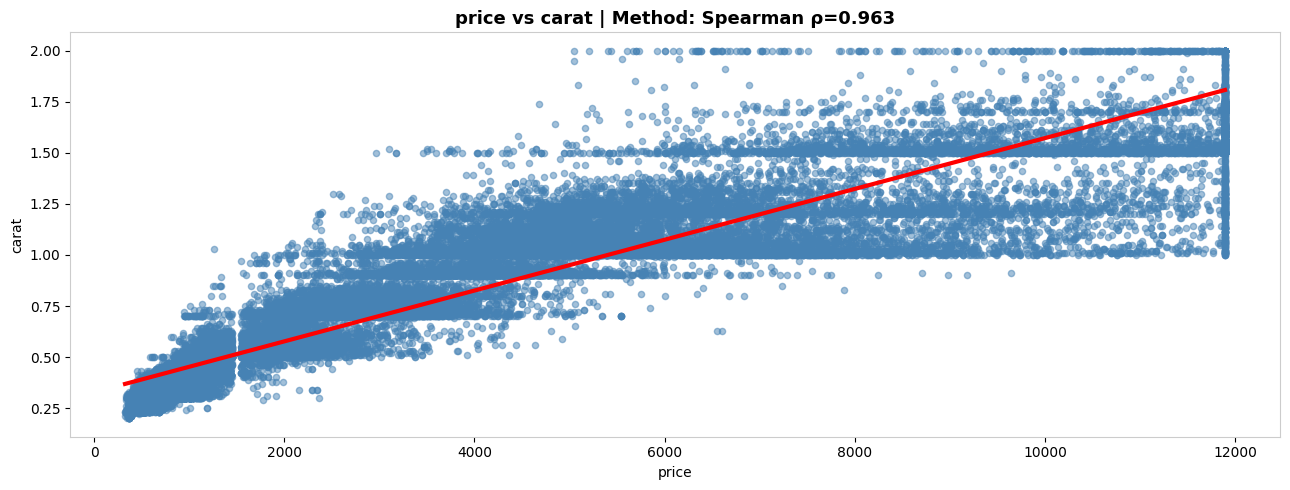

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Target: price ←→ depth
Method: Spearman Correlation
ρ: 0.010328384996251097
p-value: 0.01659655225304591
→ H₀ REJECTED: Significant correlation (p < 0.05)
Strength: Negligible positive correlation



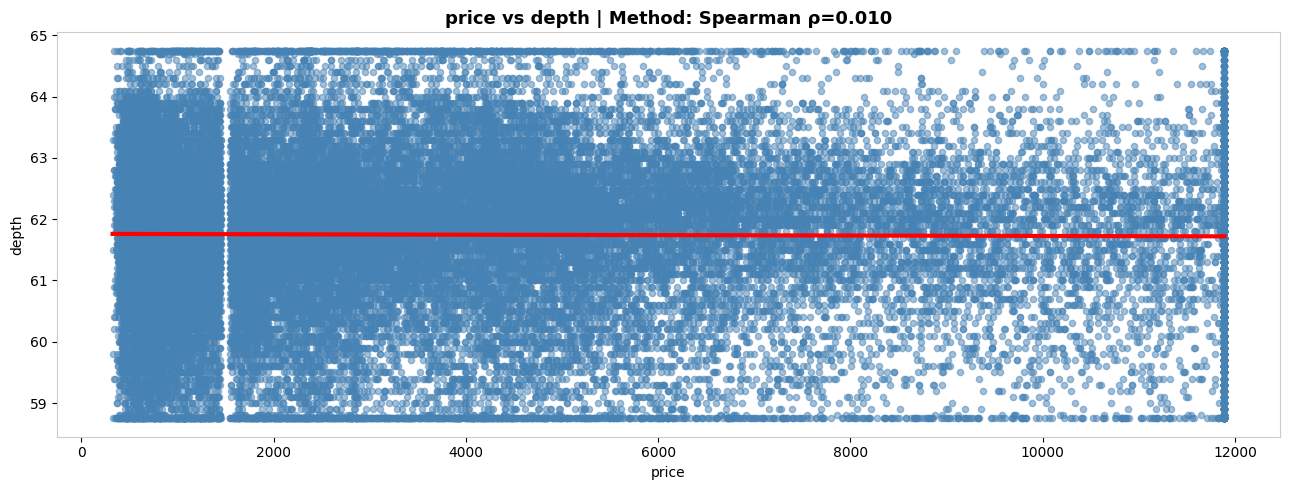

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Target: price ←→ table
Method: Spearman Correlation
ρ: 0.17090737265550135
p-value: 0.0
→ H₀ REJECTED: Significant correlation (p < 0.05)
Strength: Weak positive correlation



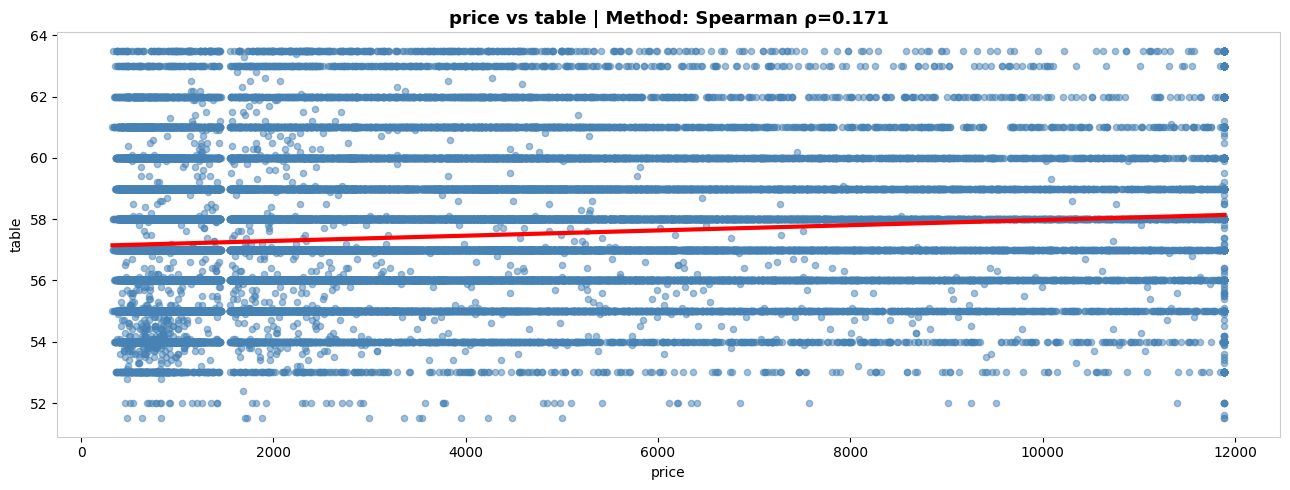

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Target: price ←→ x
Method: Spearman Correlation
ρ: 0.9631763814852438
p-value: 0.0
→ H₀ REJECTED: Significant correlation (p < 0.05)
Strength: Very strong positive correlation



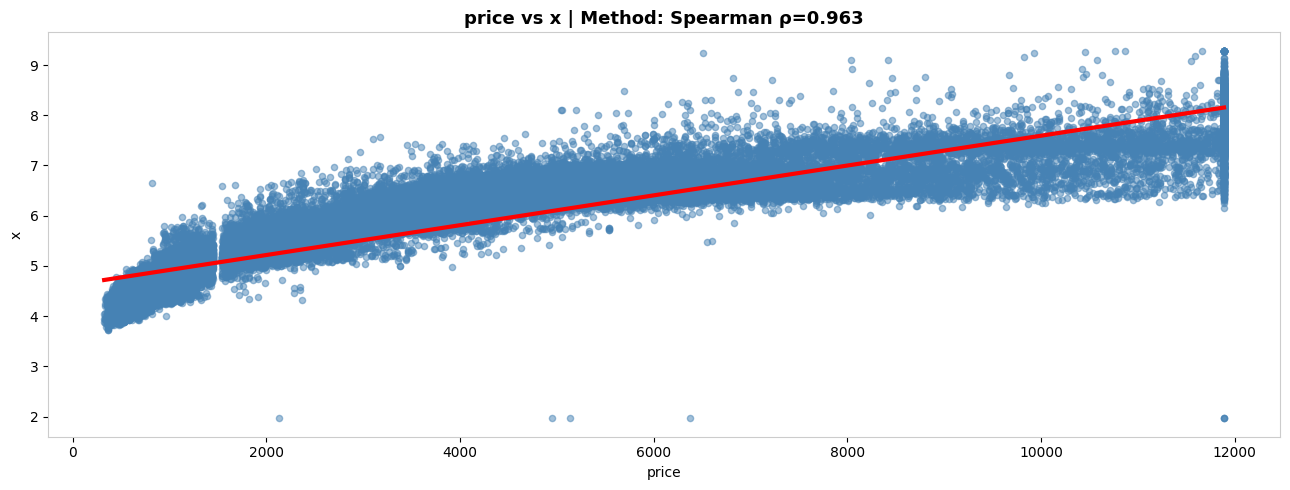

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Target: price ←→ y
Method: Spearman Correlation
ρ: 0.9627039245625132
p-value: 0.0
→ H₀ REJECTED: Significant correlation (p < 0.05)
Strength: Very strong positive correlation



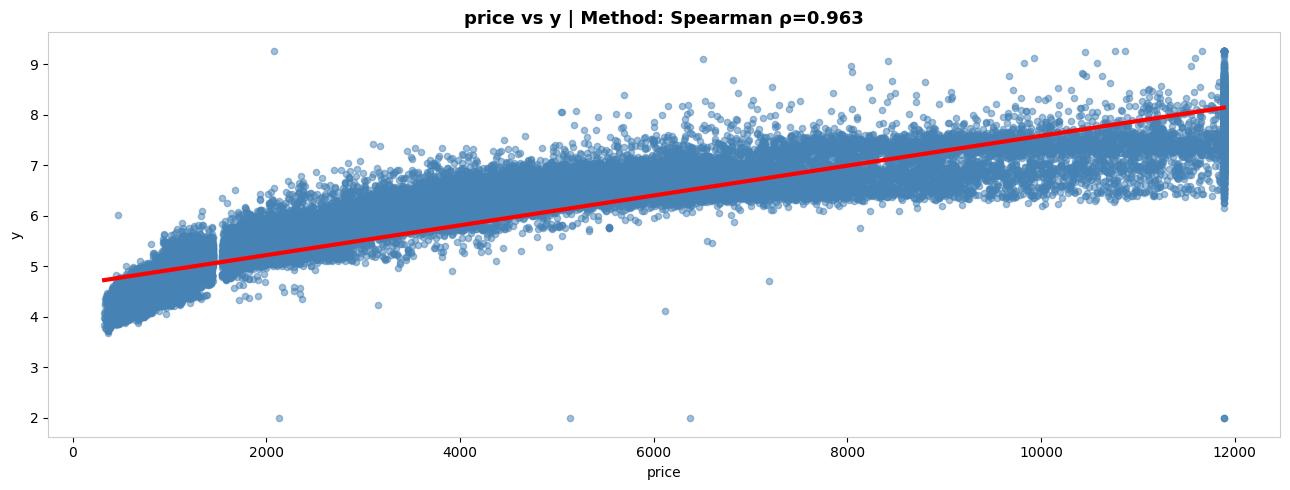

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Target: price ←→ z
Method: Spearman Correlation
ρ: 0.9572440575106476
p-value: 0.0
→ H₀ REJECTED: Significant correlation (p < 0.05)
Strength: Very strong positive correlation



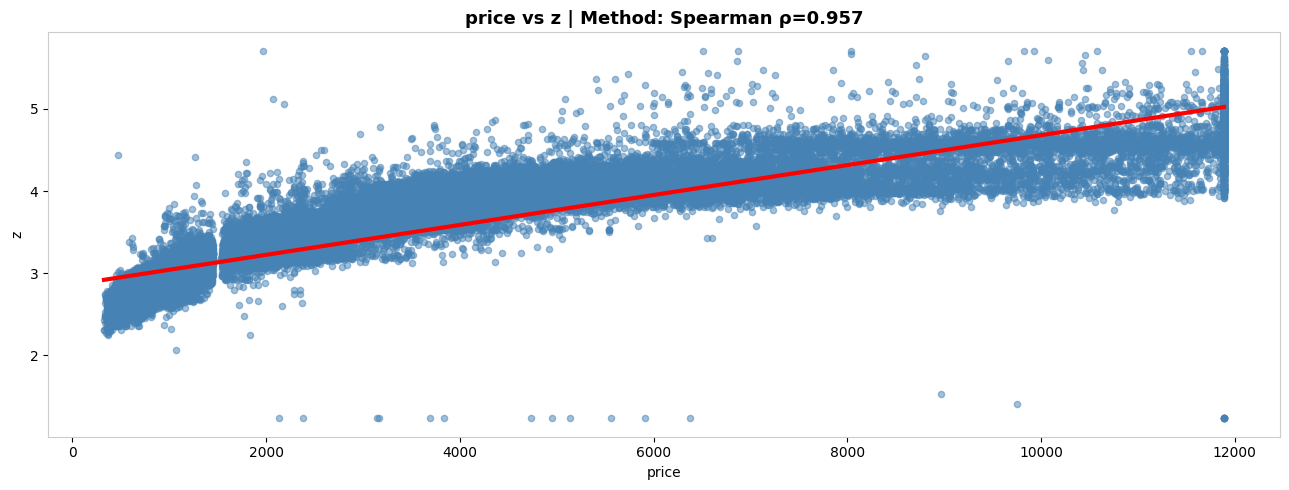

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [19]:
eda.target_summary_with_num(plot=True)

# 15. Global Multicollinearity and Correlation Heatmap
In this final step of our primary analysis, we execute the `correlation_heatmap()` method. This function generates an interactive heatmap for all numerical features in the dataset. By default, it uses the **Spearman** rank correlation (which is more robust to non-linear relationships and outliers), but it can also perform Pearson or Kendall correlations. This visualization is key for detecting **multicollinearity**—where two or more independent variables are highly correlated—which can impact the stability and interpretability of future machine learning models.

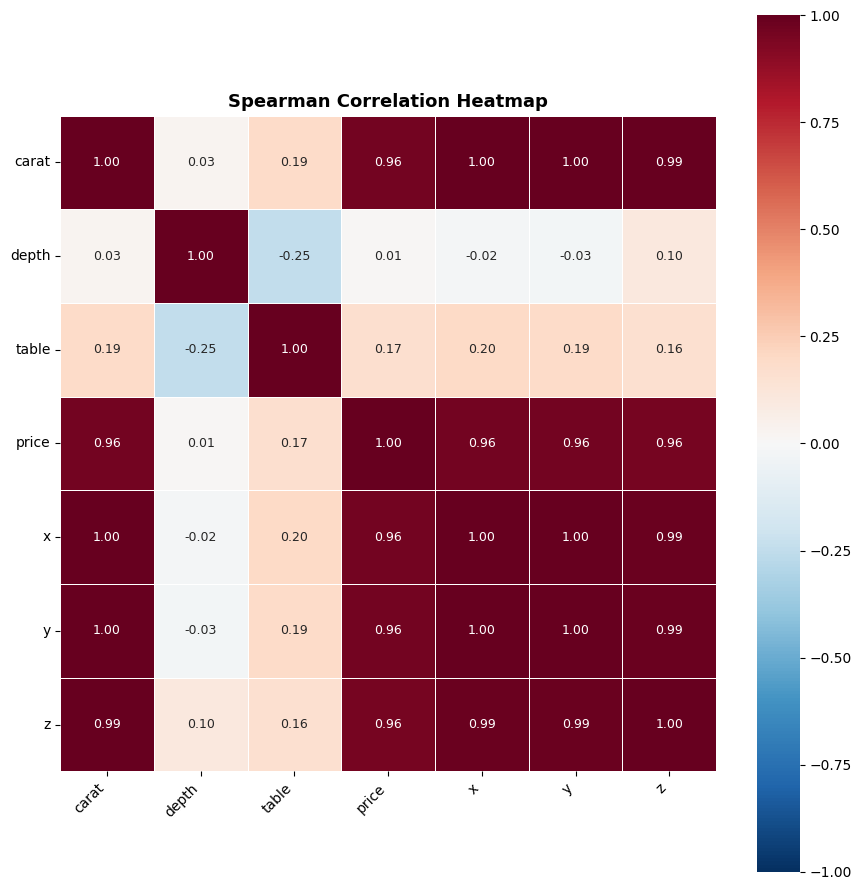

In [20]:
eda.correlation_heatmap()